In [ ]:
# Core
import numpy as np
import pandas as pd

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
np.random.seed(42)
n_transactions = 1000

data = {
    'amount': np.random.exponential(5000, n_transactions),
    'hour_of_day': np.random.randint(0, 24, n_transactions),
    'is_weekend': np.random.choice([0, 1], n_transactions),
    'distance_from_home': np.random.exponential(50, n_transactions),
    'online_transaction': np.random.choice([0, 1], n_transactions),
    'transaction_count_24h': np.random.randint(1, 20, n_transactions),
}

df = pd.DataFrame(data)

# Fraud logic
fraud_score = (
    (df['amount'] > 10000).astype(int) +
    ((df['hour_of_day'] > 22) | (df['hour_of_day'] < 5)).astype(int) +
    (df['distance_from_home'] > 100).astype(int) +
    (df['transaction_count_24h'] > 10).astype(int)
)

df['is_fraud'] = (fraud_score >= 2).astype(int)

# Add noise
noise_idx = np.random.choice(n_transactions, int(0.03 * n_transactions), replace=False)
df.loc[noise_idx, 'is_fraud'] = 1 - df.loc[noise_idx, 'is_fraud']

print(f"Fraud Rate: {df['is_fraud'].mean()*100:.2f}%")


Fraud Rate: 27.10%


In [5]:
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [6]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:, 1]


In [7]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]


In [8]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:, 1]


In [9]:
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    'Precision': [
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    'Recall': [
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    'F1 Score': [
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, dt_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
}).set_index('Model')

print("\n=== MODEL COMPARISON ===")
print(results.round(4))



=== MODEL COMPARISON ===
               Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                        
Decision Tree     0.920     0.8393  0.8704    0.8545   0.9044
Random Forest     0.965     1.0000  0.8704    0.9307   0.9528
XGBoost           0.965     0.9796  0.8889    0.9320   0.9614


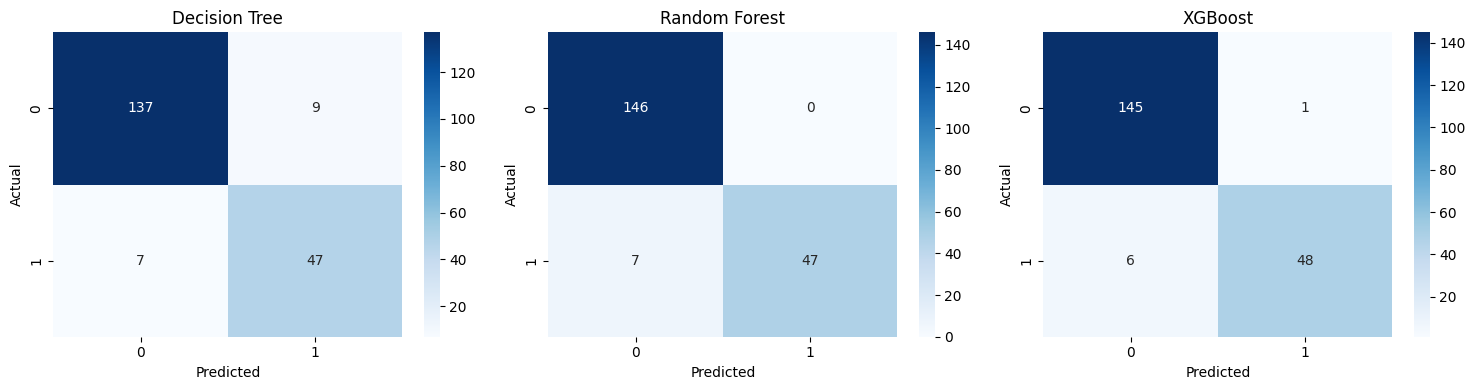

In [10]:
models = {
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


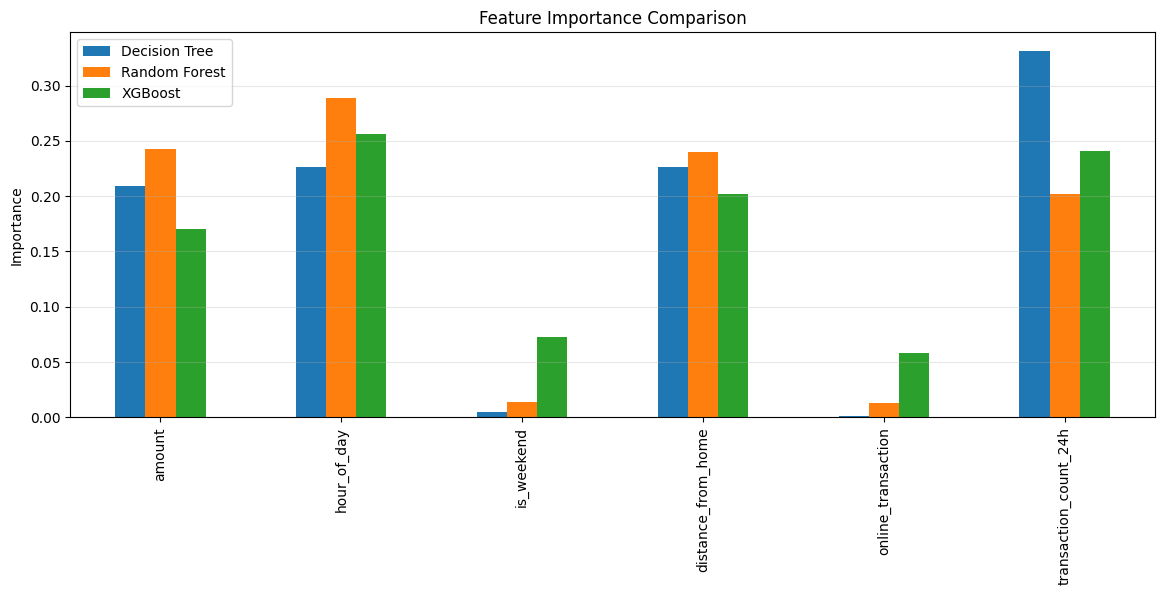

In [11]:
fi = pd.DataFrame({
    'Decision Tree': dt.feature_importances_,
    'Random Forest': rf.feature_importances_,
    'XGBoost': xgb.feature_importances_
}, index=X.columns)

fi.plot(kind='bar', figsize=(14,5))
plt.title("Feature Importance Comparison")
plt.ylabel("Importance")
plt.grid(axis='y', alpha=0.3)
plt.show()


📌 Decision Tree

Single model

High variance

Fully interpretable

Overfits easily

📌 Random Forest

Bagging (parallel trees)

Lower variance

Stable & reliable

Less interpretable

📌 XGBoost

Boosting (sequential learning)

Focuses on mistakes

Best performance

Industry standard for tabular data

🎯 ONE-LINE INTERVIEW ANSWER

“I start with a Decision Tree for interpretability, move to Random Forest to reduce variance using bagging, and finally use XGBoost to maximize performance through gradient boosting.”